In [1]:
# dropout, bn, 自定义图片数据集
# 迁移学习

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [3]:
base_dir = './dataset/image'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

In [4]:
filenames = os.listdir('./dataset/image')

In [5]:
len(filenames)

1127

In [5]:
species = ['cloudy', 'rain', 'shine', 'sunrise']

In [16]:
# 创建train和test目录
if not os.path.exists(train_dir):
    os.mkdir(train_dir)
if not os.path.exists(test_dir):
    os.mkdir(test_dir)

In [17]:
# 分别在train和test目录下创建4种类别的目录
for train_or_test in ['train', 'test']:
    for spec in species:
        path = os.path.join(base_dir, train_or_test , spec)
        os.mkdir(path)

In [6]:
# python中的自带的拷贝工具
import shutil

In [20]:
# 要判断一个图片属于哪个类别
# 'cloudy' in img

In [25]:
# 要把dataset中的图片全部拷贝到train, test目录下的4个子目录中
for i, img in enumerate(filenames):
    img_path = os.path.join(base_dir, img)

    if os.path.isdir(img_path):
        continue
    for spec in species:
        if spec in img:
            # 确定是划分为 test 还是 train
            # sub_folder = 'test' if i % 5 == 0 else 'train'
            
            # # 构建目标目录路径 (例如: ./dataset/image/train/cat)
            # target_dir = os.path.join(base_dir, sub_folder, spec)
            
            # # 【关键修改 2】如果目标文件夹不存在，则递归创建
            # if not os.path.exists(target_dir):
            #     os.makedirs(target_dir)
            
            # # 构建完整的目标文件路径
            # target_path = os.path.join(target_dir, img)
            
            # # 执行复制
            # shutil.copy(img_path, target_path)
            # break # 匹配到一个物种后即可跳出内层循环
            if i % 5 == 0:
                path = os.path.join(base_dir, 'test', spec, img)
            else:
                path = os.path.join(base_dir, 'train', spec, img)
            shutil.copy(img_path, path)

In [26]:
# 打印每个类别训练数据和测试数据分别有多少图片
for train_or_test in ['train', 'test']:
    for spec in species:
        print(train_or_test, spec, len(os.listdir(os.path.join(base_dir, train_or_test, spec))))


train cloudy 240
train rain 172
train shine 202
train sunrise 286
test cloudy 60
test rain 43
test shine 51
test sunrise 71


In [7]:
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    # 统一缩放到 96 * 96
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    # 正则化
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [9]:
train_ds = torchvision.datasets.ImageFolder(train_dir, transform=transform)

In [10]:
test_ds = torchvision.datasets.ImageFolder(test_dir, transform=transform)

In [33]:
train_ds.classes

['cloudy', 'rain', 'shine', 'sunrise']

In [34]:
train_ds.class_to_idx

{'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

In [35]:
len(train_ds)

900

In [36]:
len(test_ds)

225

In [11]:
batch_size = 32

In [12]:
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=batch_size)

In [41]:
imgs, labels = next(iter(train_dl))

In [42]:
imgs.shape

torch.Size([32, 3, 96, 96])

In [43]:
labels

tensor([1, 2, 3, 2, 0, 0, 1, 0, 2, 1, 2, 0, 3, 2, 3, 1, 2, 0, 2, 2, 3, 0, 0, 1,
        2, 1, 2, 0, 2, 3, 3, 3])

In [46]:
# 显示一张图片
img = imgs[0]
img.shape

torch.Size([3, 96, 96])

In [47]:
# squeeze, 只能把维度是1的地方压缩掉   (28, 28, 1) -> (28, 28)

In [53]:
# torch.transpose()
img
img.min()
img.max()
img = img + 1
img = img/2
img

tensor([[[0.5392, 0.5627, 0.5902,  ..., 0.5196, 0.5510, 0.5627],
         [0.5314, 0.5745, 0.5510,  ..., 0.5431, 0.5196, 0.5275],
         [0.5314, 0.6176, 0.5627,  ..., 0.5431, 0.5353, 0.5471],
         ...,
         [0.8294, 0.8294, 0.8294,  ..., 0.8647, 0.7863, 0.8412],
         [0.8059, 0.8137, 0.8098,  ..., 0.8412, 0.7863, 0.8137],
         [0.8608, 0.8725, 0.8647,  ..., 0.8882, 0.8294, 0.8412]],

        [[0.5392, 0.5627, 0.5902,  ..., 0.5196, 0.5510, 0.5627],
         [0.5314, 0.5745, 0.5510,  ..., 0.5431, 0.5196, 0.5275],
         [0.5314, 0.6176, 0.5627,  ..., 0.5431, 0.5353, 0.5471],
         ...,
         [0.8333, 0.8333, 0.8333,  ..., 0.9000, 0.8216, 0.8686],
         [0.8098, 0.8176, 0.8137,  ..., 0.8765, 0.8216, 0.8451],
         [0.8647, 0.8765, 0.8686,  ..., 0.9235, 0.8647, 0.8765]],

        [[0.5353, 0.5549, 0.5824,  ..., 0.5157, 0.5431, 0.5627],
         [0.5275, 0.5706, 0.5471,  ..., 0.5392, 0.5157, 0.5275],
         [0.5235, 0.6098, 0.5549,  ..., 0.5353, 0.5275, 0.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.4529412].


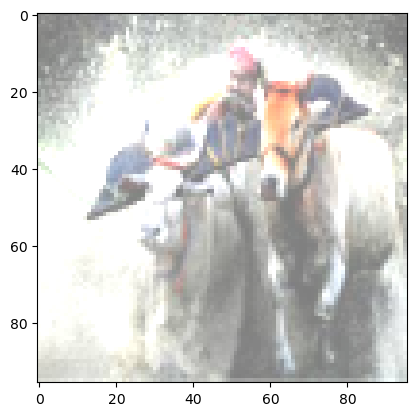

In [54]:
# reshape不可以, 会打乱数据
plt.imshow(img.permute(1, 2, 0))

In [35]:
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # 16 * 94 * 94
        self.pool = nn.MaxPool2d(2, 2) # 16 * 47 *47
        self.conv2 = nn.Conv2d(16, 32, 3) # 32 * 45 * 45 -> pooling -> 32 * 22 * 22
        self.conv3 = nn.Conv2d(32, 64, 3) # 64 * 20 * 20 -> pooling -> 64 * 10 * 10
        self.dropout = nn.Dropout()

        # batch, channel, height, width, 64
        self.fc1 = nn.Linear(64 * 10 * 10, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # x.view(-1, 64 * 10 * 10)
        x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [14]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [15]:
model = Net()
# 把model拷到GPU上
if torch.cuda.is_available():
    model.to(device)

In [16]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [36]:
def fit(epoch, model, train_loader, test_loader):
    correct = 0
    total = 0
    running_loss = 0

    for x, y in train_loader:
        # 把数据放到GPU上去.
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            y_pred = torch.argmax(y_pred, dim=1)
            correct += (y_pred == y).sum().item()
            total += y.size(0)
            running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # 测试过程
    test_correct = 0
    test_total = 0
    test_running_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            # 把数据放到GPU上去.
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
 
            y_pred = torch.argmax(y_pred, dim=1)
            test_correct += (y_pred == y).sum().item()
            test_total += y.size(0)
            test_running_loss += loss.item()

    test_epoch_loss = test_running_loss / len(test_loader.dataset)
    test_epoch_acc = test_correct / test_total

    print('epoch: ', epoch,
         'loss: ', round(epoch_loss, 3),
         'accuracy: ', round(epoch_acc, 3),
         'test_loss: ', round(test_epoch_loss, 3),
         'test_accuracy: ', round(test_epoch_acc, 3)
         )
    return epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc

In [18]:
epochs = 20
train_loss = []
train_acc = []
test_loss = []
test_acc = []
for epoch in range(epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc =  fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)

epoch:  0 loss:  0.027 accuracy:  0.603 test_loss:  0.023 test_accuracy:  0.742
epoch:  1 loss:  0.017 accuracy:  0.764 test_loss:  0.019 test_accuracy:  0.822
epoch:  2 loss:  0.016 accuracy:  0.806 test_loss:  0.019 test_accuracy:  0.831
epoch:  3 loss:  0.014 accuracy:  0.83 test_loss:  0.016 test_accuracy:  0.853
epoch:  4 loss:  0.012 accuracy:  0.856 test_loss:  0.016 test_accuracy:  0.853
epoch:  5 loss:  0.011 accuracy:  0.884 test_loss:  0.017 test_accuracy:  0.871
epoch:  6 loss:  0.012 accuracy:  0.859 test_loss:  0.017 test_accuracy:  0.871
epoch:  7 loss:  0.008 accuracy:  0.904 test_loss:  0.017 test_accuracy:  0.893
epoch:  8 loss:  0.008 accuracy:  0.899 test_loss:  0.013 test_accuracy:  0.884
epoch:  9 loss:  0.007 accuracy:  0.926 test_loss:  0.017 test_accuracy:  0.884
epoch:  10 loss:  0.005 accuracy:  0.943 test_loss:  0.021 test_accuracy:  0.88
epoch:  11 loss:  0.006 accuracy:  0.93 test_loss:  0.017 test_accuracy:  0.889
epoch:  12 loss:  0.005 accuracy:  0.946 

In [21]:
torch.save(model.state_dict(), './my_model.pth')

In [40]:
# 恢复模型
new_model = Net()


In [39]:
new_model.load_state_dict(torch.load('./my_model.pth'))

RuntimeError: Error(s) in loading state_dict for Net:
	Unexpected key(s) in state_dict: "bn1.weight", "bn1.bias", "bn1.running_mean", "bn1.running_var", "bn1.num_batches_tracked", "bn2.weight", "bn2.bias", "bn2.running_mean", "bn2.running_var", "bn2.num_batches_tracked", "bn3.weight", "bn3.bias", "bn3.running_mean", "bn3.running_var", "bn3.num_batches_tracked", "bn_fc1.weight", "bn_fc1.bias", "bn_fc1.running_mean", "bn_fc1.running_var", "bn_fc1.num_batches_tracked", "bn_fc2.weight", "bn_fc2.bias", "bn_fc2.running_mean", "bn_fc2.running_var", "bn_fc2.num_batches_tracked". 

In [24]:
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[ 0.0762, -0.1825,  0.0058],
                        [-0.0743,  0.0901,  0.1316],
                        [-0.1100,  0.1008, -0.0280]],
              
                       [[-0.1041, -0.0642,  0.0996],
                        [ 0.0360,  0.0926,  0.0172],
                        [ 0.1390,  0.0841,  0.0689]],
              
                       [[-0.1752, -0.1321, -0.0016],
                        [-0.0466,  0.1309, -0.0985],
                        [ 0.1101, -0.1583, -0.1852]]],
              
              
                      [[[ 0.1275,  0.1339, -0.0373],
                        [ 0.1696,  0.1593,  0.0835],
                        [ 0.0219,  0.1023,  0.1835]],
              
                       [[ 0.0641,  0.0546, -0.0003],
                        [ 0.0538,  0.0798,  0.0696],
                        [-0.0363,  0.0081,  0.1654]],
              
                       [[ 0.1077,  0.0588, -0.1251],
                        [ 

In [41]:
new_model.to(device)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=6400, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=4, bias=True)
)

In [26]:
test_correct = 0
test_total = 0
new_model.eval()
with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        y_pred = new_model(x)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct += (y_pred == y).sum().item()
        test_total += y.size(0)

epoch_test_acc = test_correct / test_total
print(epoch_test_acc)

0.26666666666666666


### 1 保存最优参数

In [42]:
model = Net()
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [43]:
import copy

In [44]:
# 没有训练之前的初始化参数
best_model_weight =  model.state_dict()

best_acc = 0.0

train_loss = []
train_acc = []
test_loss = []
test_acc = []

for epoch in range(epochs):
    epoch_loss, epoch_acc, epoch_test_loss, epoch_test_acc = fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    test_loss.append(epoch_test_loss)
    test_acc.append(epoch_test_acc)

    if epoch_test_acc > best_acc:
        best_acc = epoch_test_acc
        # 更新参数
        best_model_weight = copy.deepcopy(model.state_dict())



epoch:  0 loss:  0.028 accuracy:  0.576 test_loss:  0.022 test_accuracy:  0.742
epoch:  1 loss:  0.017 accuracy:  0.801 test_loss:  0.018 test_accuracy:  0.822
epoch:  2 loss:  0.014 accuracy:  0.828 test_loss:  0.019 test_accuracy:  0.818
epoch:  3 loss:  0.011 accuracy:  0.859 test_loss:  0.016 test_accuracy:  0.84
epoch:  4 loss:  0.011 accuracy:  0.867 test_loss:  0.015 test_accuracy:  0.858
epoch:  5 loss:  0.01 accuracy:  0.889 test_loss:  0.015 test_accuracy:  0.876
epoch:  6 loss:  0.012 accuracy:  0.873 test_loss:  0.014 test_accuracy:  0.876
epoch:  7 loss:  0.01 accuracy:  0.883 test_loss:  0.013 test_accuracy:  0.858
epoch:  8 loss:  0.007 accuracy:  0.928 test_loss:  0.014 test_accuracy:  0.902
epoch:  9 loss:  0.008 accuracy:  0.912 test_loss:  0.014 test_accuracy:  0.911
epoch:  10 loss:  0.007 accuracy:  0.923 test_loss:  0.014 test_accuracy:  0.88
epoch:  11 loss:  0.006 accuracy:  0.932 test_loss:  0.015 test_accuracy:  0.893
epoch:  12 loss:  0.004 accuracy:  0.956 t

In [45]:
# 把最好的参数加载到模型中
model.load_state_dict(best_model_weight)

<All keys matched successfully>

### 2 保存完整模型

In [46]:
torch.save(model, './my_whole_model.pth')

In [48]:
new_model2 = torch.load('./my_whole_model.pth', weights_only=False)

In [49]:
new_model2.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-0.2006, -0.0280,  0.1136],
                        [ 0.1592,  0.2045, -0.0377],
                        [-0.1850, -0.1753,  0.0249]],
              
                       [[-0.1465,  0.0659,  0.0864],
                        [ 0.1510,  0.0592, -0.0454],
                        [-0.0292,  0.2115,  0.1526]],
              
                       [[-0.1808,  0.1811, -0.0292],
                        [-0.1830,  0.0931, -0.1694],
                        [-0.0305,  0.0376, -0.0595]]],
              
              
                      [[[-0.1451,  0.0456, -0.0779],
                        [ 0.0324,  0.0078,  0.0764],
                        [ 0.0679,  0.0110,  0.0449]],
              
                       [[ 0.1781,  0.1750, -0.0455],
                        [-0.0864, -0.0824, -0.0373],
                        [-0.0736, -0.1498, -0.0836]],
              
                       [[ 0.1673,  0.0035,  0.1134],
                        [ 

In [50]:
new_model2

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=6400, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=4, bias=True)
)

### 3 跨设备的模型保存和加载

In [51]:
device

device(type='cuda', index=0)

In [52]:
torch.save(model.state_dict(), './my_best_weight')

In [53]:
# 把刚才保存的模型映射到GPU上
model = Net()
# 相当于加载完模型后, 执行了model.to(device)
model.load_state_dict(torch.load('./my_best_weight', map_location=device))

<All keys matched successfully>

In [54]:
model

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=6400, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=4, bias=True)
)

In [19]:
# 添加BN层
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # 16 * 94 * 94
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2) # 16 * 47 *47
        self.conv2 = nn.Conv2d(16, 32, 3) # 32 * 45 * 45 -> pooling -> 32 * 22 * 22
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3) # 64 * 20 * 20 -> pooling -> 64 * 10 * 10
        self.bn3 = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout()

        # batch, channel, height, width, 64
        self.fc1 = nn.Linear(64 * 10 * 10, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.bn1(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.bn2(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.bn3(x)
        # x.view(-1, 64 * 10 * 10)
        x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = self.bn_fc1(x)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.bn_fc2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [20]:
model = Net()
# 把model拷到GPU上
if torch.cuda.is_available():
    model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [94]:
epochs = 20
train_loss = []
train_acc = []
test_loss = []
test_acc = []
for epoch in range(epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc =  fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 1024])